# Rapport MS COCO classification challenge

To run this notebook successfully, you need to have the MS COCO dataset downloaded and every python package installed. All python requirements are listed in the appropriate files given in the zip file and was created using uv. You can also create an.env file to provide different variables to the notebook using .env.example as a template. The notebook is structured in several sections, each of them being a code cell or a Markdown cell. You can run the notebook cell by cell, or you can run all cells at once.

## 1. Installation and imports

We start by importing all our libraries needed for this notebook. We also check the version of Python and PyTorch, and we initialize the device to be used (CPU or GPU). Setting DEVICE in the .env is not compulsory as this code will try to detect the best device available. If you want to force the use of a specific device, you can set the DEVICE variable in the .env file to `cpu`, `cuda`, or `mps` for example. If there is an issue with the execution directory, you can also set the `DIR_PATH` variable in your environment variable or change it's value directly in the code below.

In [25]:
import os
import torch
import torch.nn as nn
import torchvision
import platform
import numpy as np
import random
import matplotlib.pyplot as plt
import pandas as pd
import json
import time
import copy

from dotenv import load_dotenv
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
from torchvision import transforms, models
from torch.utils.data import DataLoader
from sklearn.metrics import f1_score, precision_score, recall_score

pwd = os.getenv("DIR_PATH", "")
os.chdir(pwd) if pwd else None

import sys

PROJECT_DIR = os.getcwd()
if PROJECT_DIR not in sys.path:
    sys.path.insert(0, PROJECT_DIR)
os.environ["PYTHONPATH"] = PROJECT_DIR + os.pathsep + os.environ.get("PYTHONPATH", "")

from lib.util import CLASSES, COCOTrainImageDataset, COCOTestImageDataset, TransformSubset

load_dotenv()

# device initialization
device_name = os.getenv("DEVICE", "")
DEVICE = torch.device(
    device_name) if device_name else (
    torch.accelerator.current_accelerator()) if (
    torch.accelerator.is_available()) else (
    torch.device("cpu"))

print("Python :", platform.python_version())
print("PyTorch :", torch.__version__)
print("Device used :", DEVICE)
print("Execution directory :", os.getcwd())

Python : 3.14.8
PyTorch : 2.14.1
Device used : mps
Execution directory : /Users/ProjetPIR/PR_CR/theo/model


Potentiel import supp à supprimer plus tard

In [26]:
import platform, math
from collections import Counter
import torch.nn.functional as F

## 2. Configuration

In this section, we will define the configuration parameters for our experiment. We start by defining the paths to the data and output directories. We strongly advise defining an appropriate DATA_ROOT corresponding to the path to the ms coco dataset either by creating a .env file or directly by replacing the default value set below. We also define some hyperparameters for training, such as the number of epochs, batch size, and learning rate. We also set a random seed for reproducibility and define a quick run option to limit the number of images processed for testing purposes. Before continuing, verify that all the output paths are correct and that the dataset is accessible.

In [27]:
# Defining global variables for data directories
DATA_ROOT = Path(os.getenv("DATA_ROOT", "/opt/iav/labs/data"))
DATA_ROOT = DATA_ROOT / "ms-coco"
IMAGE_DIR = DATA_ROOT / "images/train"
LABEL_DIR = DATA_ROOT / "labels/train"
TEST_IMAGE_DIR = DATA_ROOT / "images/test"

# Defining global variables for output directories
OUTPUT_DIR = Path(os.getenv("OUTPUT_DIR", "output"))
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
JSON_PATH = OUTPUT_DIR / os.getenv("JSON_PATH", "submission.json")

SEED = 30
EPOCHS = 20
BATCH_SIZE = 32
NUM_WORKERS = min(8, os.cpu_count() or 1)
IMAGE_SIZE = 224
PATIENCE = 5
TRANSFORM = True

# Fraction of the dataset to be used for validation
VAL_FRACTION = 0.15

# Probability threshold above which a class is predicted
THRESHOLD = 0.5

# For a quick run, you can set QUICK_RUN to True and limit the number of images processed
QUICK_RUN = False
QUICK_MAX_IMAGES = 5000

# Pin memory for faster data transfer to GPU if using CUDA
PIN_MEMORY = DEVICE.type == "cuda"


# Function to set random seed for reproducibility
def set_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = (DEVICE.type == "cuda")


set_seed()

print("Images :", IMAGE_DIR.resolve())
print("Annotations :", LABEL_DIR.resolve())
print("Test images :", TEST_IMAGE_DIR.resolve())
print("Outputs :", OUTPUT_DIR.resolve())
print("Submission :", JSON_PATH.resolve())

Images : /Users/ProjetPIR/PR_CR/theo/model/data/ms-coco/images/train
Annotations : /Users/ProjetPIR/PR_CR/theo/model/data/ms-coco/labels/train
Test images : /Users/ProjetPIR/PR_CR/theo/model/data/ms-coco/images/test
Outputs : /Users/ProjetPIR/PR_CR/theo/model/output_old
Submission : /Users/ProjetPIR/PR_CR/theo/model/output_old/submission.json


## 3. Classes definitions and files verification

Here we define the classes and verify that we can access the images and annotations. If everything works fine, you should see the number of images and annotations found, and they should be equal to each other (Normally, there is 65 000 images if the dataset is correctly downloaded). You should also see an example of an image and its corresponding annotation file.

In [29]:
classes = CLASSES
NUM_CLASSES = len(classes)
assert NUM_CLASSES == 80, f"We expect to find 80 classes but {NUM_CLASSES} were found."

if not IMAGE_DIR.is_dir() or not LABEL_DIR.is_dir():
    raise FileNotFoundError(
        f"Dataset not found. Verify DATA_ROOT={DATA_ROOT.resolve()} ; "
        f"There must be a folder 'images/train' and a folder 'labels/train' containing the .jpg images and .cls annotation files respectively."
    )

test_images = sorted(IMAGE_DIR.glob("*.jpg"))
label_files = sorted(LABEL_DIR.glob("*.cls"))

if not test_images:
    raise RuntimeError("No .jpg files found in IMAGE_DIR.")
if not label_files:
    raise RuntimeError("No .cls files found in LABEL_DIR.")

print(f"Images : {len(test_images):,}")
print(f"Annotated files : {len(label_files):,}")
print("Image example :", test_images[0].name if test_images else None)
print("annotation example :", label_files[0].name if label_files else None)

if len(test_images) != len(label_files):
    print(
        f"Warning: Number of images ({len(test_images)}) does not match number of labels ({len(label_files)}). Some images may not have corresponding labels or vice versa.")

Images : 65,000
Annotated files : 65,000
Image example : 000000000009.jpg
annotation example : 000000000009.cls


## 4. Annotations analysis

Before going straight to the training part, we will analyze the annotations to see the distribution of classes before any training in order to analyse the composition of the dataset.

Annotations analysis:   0%|          | 0/65000 [00:00<?, ?it/s]

Images analysed : 65000
Annotations problematic : 0
Average number of classes/image : 2.926
Median : 2.0
Min :  1
Max :  18


,class,images_positives
78,hair drier,102
70,toaster,117
12,parking meter,396
21,bear,516
76,scissors,555
...,...,...
41,cup,5057
60,dining table,6546
2,car,6811
56,chair,7043


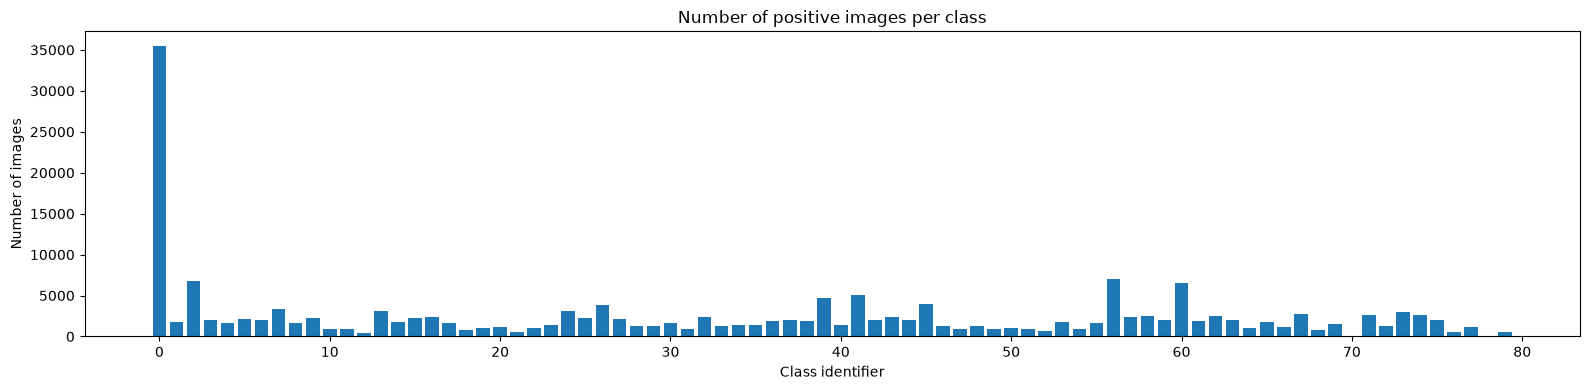

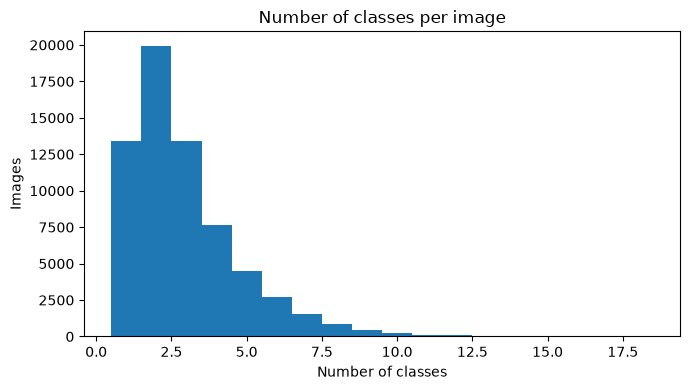

In [30]:
scan_files = label_files[:QUICK_MAX_IMAGES] if QUICK_RUN else label_files
class_counts = np.zeros(NUM_CLASSES, dtype=np.int64)
labels_per_image = []
invalid_rows = []

for p in tqdm(scan_files, desc="Annotations analysis"):
    try:
        ids = [int(x.strip()) for x in p.read_text().splitlines() if x.strip()]
        if any(i < 0 or i >= NUM_CLASSES for i in ids):
            invalid_rows.append(p.name)
            continue
        class_counts[np.unique(ids)] += 1
        labels_per_image.append(len(set(ids)))
    except Exception as e:
        print(f"Error processing {p.name}: {e}")
        invalid_rows.append(p.name)

print("Images analysed :", len(scan_files))
print("Annotations problematic :", len(invalid_rows))
print("Average number of classes/image :", round(float(np.mean(labels_per_image)), 3))
print("Median :", float(np.median(labels_per_image)))
print("Min : ", min(labels_per_image))
print("Max : ", max(labels_per_image))

# Displaying the distribution of images per class in a DataFrame
freq_df = pd.DataFrame({"class": classes, "images_positives": class_counts})
display(freq_df.sort_values("images_positives"))

# Distribution of the number of images per class
plt.figure(figsize=(16, 4))
plt.bar(np.arange(NUM_CLASSES), class_counts)
plt.title("Number of positive images per class")
plt.xlabel("Class identifier")
plt.ylabel("Number of images")
plt.tight_layout()
plt.show()

# Distribution of the number of classes per image
plt.figure(figsize=(7, 4))
plt.hist(labels_per_image, bins=range(1, max(labels_per_image) + 2), align="left")
plt.title("Number of classes per image")
plt.xlabel("Number of classes")
plt.ylabel("Images")
plt.tight_layout()
plt.show()

As we can see, the distribution of classes is highly imbalanced. Firstly, the class "person" is the most represented class by far with 37,000 images. This means that the dataset is heavily biased towards images containing people, which could potentially lead to biased model predictions if not addressed properly. We also have classes with very few images, such as `hair drier` or `toaster` with only roughly 100 images. This extreme imbalance can make it difficult for the model to learn to recognize these underrepresented classes, leading to poor performance on them. The average number of classes per image is around three, which indicates that most images contain multiple objects without overflowing with too many classes. The median number of classes per image is two, which means that half of the images contain two or fewer classes going in the direction of a low number of classes per image.

## 5. Dataset PyTorch

The PyTorch Dataset classes for training and testing are defined in `lib/util.py` and imported at the beginning of this notebook. These classes will handle loading the images and their corresponding labels, applying any necessary transformations, and preparing the data for training and evaluation. They are based on the provided function given in the starting notebook.

## 6. Transformations and DataLoaders

Here we define the transformations to be applied to the images if set, and we create the training and validation datasets and dataloaders. Because the original COCO classes don't allow us to use different transformations for training and validation, we create a `TransformSubset` class that allows us to apply different transformations to the training and validation subsets. We also split the dataset into training and validation sets based on the defined `VAL_FRACTION`.

In [31]:
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.15, contrast=0.15, saturation=0.10),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
])

resize_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])

max_images = QUICK_MAX_IMAGES if QUICK_RUN else None
base_dataset = COCOTrainImageDataset(IMAGE_DIR, LABEL_DIR, transform=None,
                                     maximum_images=max_images) if TRANSFORM else COCOTrainImageDataset(IMAGE_DIR,
                                                                                                        LABEL_DIR,
                                                                                                        transform=resize_transform,
                                                                                                        maximum_images=max_images)
n_val = max(1, int(len(base_dataset) * VAL_FRACTION))
n_train = len(base_dataset) - n_val
generator = torch.Generator().manual_seed(SEED)
train_subset, val_subset = torch.utils.data.random_split(base_dataset, [n_train, n_val], generator=generator)

train_ds = TransformSubset(train_subset, train_transform) if TRANSFORM else train_subset
val_ds = TransformSubset(val_subset, val_transform) if TRANSFORM else val_subset

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                          persistent_workers=NUM_WORKERS > 0)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                        persistent_workers=NUM_WORKERS > 0)

print(f"Train : {len(train_ds):,} | Validation : {len(val_ds):,}")

Train : 55,250 | Validation : 9,750


## 7. Metrics computation

Here we define the functions to compute the metrics used for evaluation. We will use F1 score, precision, and recall as our main metrics. We mainly use function that were in the starting notebook or from `sklearn.metrics` library. The goal here is to have metrics to compare our models before the submission to the leaderboard and the final score.

In [32]:
def compute_metrics(y_true, y_prob, threshold=THRESHOLD):
    y_pred = (y_prob >= threshold).astype(np.uint8)
    return {
        "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
        "f1_micro": f1_score(y_true, y_pred, average="micro", zero_division=0),
        "precision_macro": precision_score(y_true, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_true, y_pred, average="macro", zero_division=0),
    }


def compute_class_metrics(class_prec, class_recall):
    class_results = []
    for p, r in zip(class_prec, class_recall):
        f1 = (0 if p == r == 0 else 2. / (1 / p + 1 / r))
        class_results.append({"f1": f1, "precision": p, "recall": r})
    return class_results


@torch.no_grad()
def predict_loader(model, loader, device=DEVICE):
    model.eval()
    probs_all, targets_all = [], []
    for images, targets in tqdm(loader, leave=False):
        logits = model(images.to(device, non_blocking=True))
        probs_all.append(torch.sigmoid(logits).cpu().numpy())
        targets_all.append(targets.numpy())
    return np.concatenate(targets_all), np.concatenate(probs_all)


def inverse_frequency_weighted_f1(y_true, y_pred):
    positives = y_true.sum(axis=0)
    tp = ((y_true == 1) & (y_pred == 1)).sum(axis=0)
    fp = ((y_true == 0) & (y_pred == 1)).sum(axis=0)
    precision = np.divide(tp, tp + fp, out=np.zeros_like(tp, dtype=float), where=(tp + fp) > 0)
    recall = np.divide(tp, positives, out=np.zeros_like(tp, dtype=float), where=positives > 0)
    weights = np.divide(1.0, positives, out=np.zeros_like(positives, dtype=float), where=positives > 0)
    if weights.sum() == 0: return 0.0
    weights = weights / weights.sum()
    p, r = np.sum(precision * weights), np.sum(recall * weights)
    return 0.0 if p + r == 0 else 2 * p * r / (p + r)


def threshold_sweep(y_true, y_prob, thresholds=np.arange(0.05, 0.96, 0.05)):
    rows = []
    for t in thresholds:
        y_pred = (y_prob >= t).astype(np.uint8)
        rows.append({
            "threshold": round(float(t), 2),
            "f1_leaderboard": inverse_frequency_weighted_f1(y_true, y_pred),
            "f1_macro": f1_score(y_true, y_pred, average="macro", zero_division=0),
            "f1_micro": f1_score(y_true, y_pred, average="micro", zero_division=0),
        })
    sweep_df = pd.DataFrame(rows)
    best = sweep_df.loc[sweep_df["f1_leaderboard"].idxmax()]
    return sweep_df, best

## 8. Pretrained models and training functions

Here, we initialize our pretrained models. Since these models have already been trained on ImageNet, we replace their classification head with a new 80-output layer and either fine-tune the whole network or freeze every layer except this new head (`fc` for ResNets, `classifier` for EfficientNet). We decided to use pretrained model, because these model are already trained on huge dataset who well represent objects in our common life. We think that this is the best solution with the limited dataset that we have to obtain great results

In [33]:
def build_model(backbone="resnet18", pretrained=True, freeze_backbone=False):
    if backbone == "resnet18":
        weights = models.ResNet18_Weights.DEFAULT if pretrained else None
        model = models.resnet18(weights=weights)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, NUM_CLASSES)
        if freeze_backbone:
            for name, p in model.named_parameters():
                if not name.startswith("fc."): p.requires_grad = False
    elif backbone == "resnet50":
        weights = models.ResNet50_Weights.DEFAULT if pretrained else None
        model = models.resnet50(weights=weights)
        in_features = model.fc.in_features
        model.fc = nn.Linear(in_features, NUM_CLASSES)
        if freeze_backbone:
            for name, p in model.named_parameters():
                if not name.startswith("fc."): p.requires_grad = False
    elif backbone == "efficientnet_b0":
        weights = models.EfficientNet_B0_Weights.DEFAULT if pretrained else None
        model = models.efficientnet_b0(weights=weights)
        in_features = model.classifier[1].in_features
        model.classifier[1] = nn.Linear(in_features, NUM_CLASSES)
        if freeze_backbone:
            for name, p in model.named_parameters():
                if not name.startswith("classifier."): p.requires_grad = False
    else:
        raise ValueError(f"Backbone non pris en charge : {backbone}")
    return model.to(DEVICE)


def make_criterion(loss_name, train_targets=None):
    if loss_name == "bce":
        return nn.BCEWithLogitsLoss()
    if loss_name == "weighted_bce":
        if train_targets is None: raise ValueError("train_targets requis pour weighted_bce")
        pos = train_targets.sum(axis=0)
        neg = len(train_targets) - pos
        pos_weight = torch.tensor(neg / np.maximum(pos, 1), dtype=torch.float32, device=DEVICE)
        return nn.BCEWithLogitsLoss(pos_weight=pos_weight)
    raise ValueError("Pour la Focal Loss, ajouter/valider une implémentation dédiée avant comparaison.")

## 9.Training and evaluation loop

Here is the training loop for our experiments. We will train the model for a number of epochs, and after each epoch, we will evaluate the model on the validation set. We will keep track of the best model based on validation loss and save it to disk. It is inspired by the training loop and validation loop functions provided in the starting notebook.

In [34]:
def fit_experiment(name, backbone="resnet18", pretrained=True, freeze_backbone=False, loss_name="bce", lr=1e-4,
                   epochs=EPOCHS):
    model = build_model(backbone, pretrained, freeze_backbone)

    # Calcul des cibles train pour la loss pondérée, si sélectionnée.
    train_targets = []
    if loss_name == "weighted_bce":
        #todo : vérifier si on peut faire mieux que ça pour récupérer les targets du train_ds
        for _, y in DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=0):
            train_targets.append(y.numpy())
        train_targets = np.concatenate(train_targets)

    criterion = make_criterion(loss_name, train_targets)
    optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", patience=1, factor=0.5)
    best_loss, best_state, stale = float("inf"), None, 0
    history = []
    start = time.time()

    for epoch in range(epochs):
        # Training loop
        model.train()
        running, seen = 0.0, 0
        for images, targets in tqdm(train_loader, desc=f"{name} — époque {epoch + 1}/{epochs}", leave=False):
            images = images.to(DEVICE, non_blocking=True)
            targets = targets.to(DEVICE, non_blocking=True)
            optimizer.zero_grad(set_to_none=True)
            logits = model(images)
            loss = criterion(logits, targets)
            loss.backward()
            optimizer.step()
            running += loss.item() * images.size(0)
            seen += images.size(0)

        # Evaluation loop
        y_val, p_val = predict_loader(model, val_loader)

        # Validation loop
        model.eval()
        total_loss, total_n = 0.0, 0
        with torch.no_grad():
            for images, targets in val_loader:
                images, targets = images.to(DEVICE), targets.to(DEVICE)
                batch_loss = criterion(model(images), targets)
                total_loss += batch_loss.item() * images.size(0)
                total_n += images.size(0)
        val_loss = total_loss / max(total_n, 1)
        metrics = compute_metrics(y_val, p_val, threshold=THRESHOLD)
        scheduler.step(val_loss)
        row = {"experiment": name, "epoch": epoch + 1, "train_loss": running / max(seen, 1),
               "val_loss": val_loss, **metrics, "lr": optimizer.param_groups[0]["lr"]}
        history.append(row)
        print({k: round(v, 4) if isinstance(v, (float, np.floating)) else v for k, v in row.items()})
        if val_loss < best_loss:
            best_loss, stale = val_loss, 0
            best_state = copy.deepcopy(model.state_dict())
            torch.save({"model_state_dict": best_state, "backbone": backbone,
                        "pretrained": pretrained, "freeze_backbone": freeze_backbone,
                        "loss_name": loss_name, "threshold": THRESHOLD, "classes": list(classes)},
                       OUTPUT_DIR / f"{name}_best.pt")
        else:
            stale += 1
            if stale >= PATIENCE:
                print("Early stopping triggered.")
                break

    if best_state is not None:
        model.load_state_dict(best_state)
    y_val, p_val = predict_loader(model, val_loader)
    summary = {"experiment": name, "backbone": backbone, "pretrained": pretrained,
               "freeze_backbone": freeze_backbone, "loss": loss_name, "lr": lr,
               "epochs_run": len(history), "best_val_loss": best_loss,
               **compute_metrics(y_val, p_val, THRESHOLD),
               "inverse_frequency_weighted_f1": inverse_frequency_weighted_f1(y_val,
                                                                              (p_val >= THRESHOLD).astype(np.uint8)),
               "seconds": time.time() - start}
    return model, pd.DataFrame(history), summary, y_val, p_val

## 10. Experiments

Here we define every model we want to compare between each other. We will train each model for a number of epochs and evaluate them on the validation set. We will keep track of the best model based on validation loss and save it to disk. The results of each experiment will be stored in a DataFrame for later analysis.

In [35]:
EXPERIMENTS = [
    {"name": "resnet18_bce", "backbone": "resnet18", "freeze_backbone": False, "loss_name": "bce", "lr": 1e-4},
    {"name": "resnet18_frozen", "backbone": "resnet18", "freeze_backbone": True, "loss_name": "bce", "lr": 5e-4},
    {"name": "resnet50_bce", "backbone": "resnet50", "freeze_backbone": False, "loss_name": "bce", "lr": 1e-4},
    {"name": "efficientnet_b0_bce", "backbone": "efficientnet_b0", "freeze_backbone": False, "loss_name": "bce",
     "lr": 1e-4},
    {"name": "resnet18_weighted_bce", "backbone": "resnet18", "freeze_backbone": False, "loss_name": "weighted_bce",
     "lr": 1e-4},
]

#EXPERIMENTS = EXPERIMENTS[:1]

experiment_results = []
histories = {}
prediction_cache = {}
models_cache = {}

for cfg in EXPERIMENTS:
    model, hist, summary, y_val, p_val = fit_experiment(**cfg, epochs=EPOCHS)
    experiment_results.append(summary)
    histories[cfg["name"]] = hist
    prediction_cache[cfg["name"]] = (y_val, p_val)
    models_cache[cfg["name"]] = model
    pd.DataFrame(experiment_results).to_csv(OUTPUT_DIR / "experiment_results_partial.csv", index=False)

results_df = pd.DataFrame(experiment_results).sort_values("f1_macro", ascending=False)
display(results_df)
results_df.to_csv(OUTPUT_DIR / "experiment_results.csv", index=False)

resnet18_bce — époque 1/20:   0%|          | 0/1727 [00:05<?, ?it/s]

  0%|          | 0/305 [00:05<?, ?it/s]

{'experiment': 'resnet18_bce', 'epoch': 1, 'train_loss': 0.0887, 'val_loss': 0.0618, 'f1_macro': 0.51, 'f1_micro': 0.626, 'precision_macro': 0.7667, 'recall_macro': 0.4132, 'lr': 0.0001}


resnet18_bce — époque 2/20:   0%|          | 0/1727 [00:00<?, ?it/s]

  0%|          | 0/305 [00:00<?, ?it/s]

...

efficientnet_b0_bce — époque 20/20:   0%|          | 0/1727 [00:00<?, ?it/s]

  0%|          | 0/305 [00:00<?, ?it/s]

{'experiment': 'efficientnet_b0_bce', 'epoch': 20, 'train_loss': 0.022, 'val_loss': 0.0099, 'f1_macro': 0.9382, 'f1_micro': 0.9533, 'precision_macro': 0.9712, 'recall_macro': 0.9135, 'lr': 0.0001}


  0%|          | 0/305 [00:00<?, ?it/s]

AttributeError: 'TransformSubset' object has no attribute 'targets'

## 11. Results visualization

Here is the visualization of the results of the experiments. We will plot the validation loss for each experiment and display the metrics in a DataFrame. This will allow us to compare the performance of each model and select the best one for further tuning and final training.

In [ ]:
if histories:
    plt.figure(figsize=(10, 5))
    for name, hist in histories.items():
        plt.plot(hist["epoch"], hist["val_loss"], marker="o", label=name)
    plt.xlabel("Époque")
    plt.ylabel("Loss validation")
    plt.title("Comparaison des losses de validation")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

if not results_df.empty:
    display(results_df[["experiment", "f1_macro", "f1_micro", "precision_macro",
                        "recall_macro", "inverse_frequency_weighted_f1", "best_val_loss", "seconds"]])
    plt.figure(figsize=(10, 4))
    plt.bar(results_df["experiment"], results_df["f1_macro"])
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("F1 macro validation")
    plt.title("F1 macro sur validation")
    plt.tight_layout()
    plt.show()

## 12. Threshold tuning

The default threshold of 0.5 is rarely optimal for an imbalanced multi-label problem. For each trained model, we evaluate several thresholds on the validation set and keep the one maximizing the leaderboard F1 (weighted by inverse class frequency).

In [ ]:
def search_global_threshold(y_true, y_prob, metric="f1_macro"):
    candidates = np.arange(0.10, 0.91, 0.05)
    rows = []
    for th in candidates:
        m = compute_metrics(y_true, y_prob, float(th))
        rows.append({"threshold": float(th), **m})
    frame = pd.DataFrame(rows)
    best = frame.sort_values(metric, ascending=False).iloc[0]
    return float(best["threshold"]), frame


def search_per_class_thresholds(y_true, y_prob):
    candidates = np.arange(0.10, 0.91, 0.05)
    thresholds = np.full(y_true.shape[1], 0.5, dtype=float)
    for c in range(y_true.shape[1]):
        # Pour une classe sans positifs en validation, conserver un seuil prudent.
        if y_true[:, c].sum() == 0:
            continue
        scores = [f1_score(y_true[:, c], y_prob[:, c] >= th, zero_division=0) for th in candidates]
        thresholds[c] = float(candidates[int(np.argmax(scores))])
    return thresholds


# Sélection de la meilleure configuration selon F1 macro validation à seuil 0.5.
best_name = results_df.iloc[0]["experiment"]
best_model = models_cache[best_name]
y_val, p_val = prediction_cache[best_name]
best_global_threshold, threshold_table = search_global_threshold(y_val, p_val, metric="f1_macro")
per_class_thresholds = search_per_class_thresholds(y_val, p_val)

print("Configuration sélectionnée :", best_name)
print("Seuil global optimal sur validation :", best_global_threshold)
print("Métriques avec seuil 0.5 :", compute_metrics(y_val, p_val, 0.5))
print("Métriques avec seuil global optimisé :", compute_metrics(y_val, p_val, best_global_threshold))
y_pred_pc = (p_val >= per_class_thresholds[None, :]).astype(np.uint8)
print("Métriques avec seuils par classe :", compute_metrics(y_val, p_val, 0.5) if False else {
    "f1_macro": f1_score(y_val, y_pred_pc, average="macro", zero_division=0),
    "f1_micro": f1_score(y_val, y_pred_pc, average="micro", zero_division=0)
})
display(threshold_table)

## 13. Per-class metrics

After determining the optimal thresholds, we compute the precision, recall, and F1 score for each class individually. This allows us to understand how well the model performs on each specific class, especially given the imbalanced nature of the dataset. The results are stored in a DataFrame and saved to a CSV file for further analysis.

In [ ]:
y_pred = (p_val >= best_global_threshold).astype(np.uint8)
per_class = []
for c, name in enumerate(classes):
    per_class.append({
        "class": name, "positifs_validation": int(y_val[:, c].sum()),
        "precision": precision_score(y_val[:, c], y_pred[:, c], zero_division=0),
        "recall": recall_score(y_val[:, c], y_pred[:, c], zero_division=0),
        "f1": f1_score(y_val[:, c], y_pred[:, c], zero_division=0),
        "threshold_per_class": per_class_thresholds[c]
    })
per_class_df = pd.DataFrame(per_class).sort_values("f1")
display(per_class_df.head(20))
per_class_df.to_csv(OUTPUT_DIR / "per_class_validation_metrics.csv", index=False)

## 15. Test submission

We run the final model on the test set and generate a JSON file containing the predictions for the leaderboard submission.

In [ ]:
USE_PER_CLASS_THRESHOLDS = False
TEST_BATCH_SIZE = BATCH_SIZE
test_ds = COCOTestImageDataset(TEST_IMAGE_DIR, transform=train_transform)
test_loader = DataLoader(test_ds, batch_size=TEST_BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
                         persistent_workers=NUM_WORKERS > 0)

final_model.eval()
output_dict = {}
with torch.no_grad():
    for images, image_ids in tqdm(test_loader, desc="test inference"):
        probs = torch.sigmoid(final_model(images.to(DEVICE))).cpu().numpy()
        if USE_PER_CLASS_THRESHOLDS:
            pred = probs >= per_class_thresholds[None, :]
        else:
            pred = probs >= best_global_threshold
        for image_id, row in zip(image_ids, pred):
            output_dict[image_id] = np.flatnonzero(row).astype(int).tolist()

json_path = OUTPUT_DIR / "submission.json"
with open(json_path, "w", encoding="utf-8") as f:
    json.dump(output_dict, f, ensure_ascii=False, indent=2)

print("JSON created :", json_path.resolve())
print("Number of predicted images :", len(output_dict))
print("Example :", next(iter(output_dict.items())) if output_dict else "empty")

## 16. Submission verification

We verify that the generated JSON file is valid and contains the expected number of predictions and is correct.

In [ ]:
with open(json_path, "r", encoding="utf-8") as f:
    submission_check = json.load(f)

expected_ids = {p.stem for p in IMAGE_DIR.glob("*.jpg") if p.is_file()}
submitted_ids = set(submission_check)
assert submitted_ids == expected_ids, (
    f"images offset : {len(expected_ids - submitted_ids)} missing, "
    f"{len(submitted_ids - expected_ids)} unexpected."
)
for image_id, ids in submission_check.items():
    assert isinstance(image_id, str)
    assert isinstance(ids, list)
    assert all(isinstance(i, int) and 0 <= i < NUM_CLASSES for i in ids), image_id
    assert len(ids) == len(set(ids)), f"duplicate identifier {image_id}"
print("All tested passed.")
print("You can submit the file to the leaderboard :", json_path.resolve())